## Dataset Setup

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import wandb

import torch, os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.utils.prune as prune

# Try attaching to GPU
device = str(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using:', device)

plt.style.use('https://github.com/greydanus/mnist1d/raw/master/notebooks/mpl_style.txt')

Using: cuda


In [2]:
from mnist1d.data import get_dataset, get_dataset_args
from mnist1d.utils import set_seed, to_pickle, from_pickle

import sys ; sys.path.append('./mnist1d/notebooks')

In [3]:
args = get_dataset_args()
data = get_dataset(args=args)  # by default, this will download a pre-made dataset from the GitHub repo

print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Length of each input: {}".format(data['x'].shape[-1]))
print("Number of classes: {}".format(len(data['templates']['y'])))

File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl
Examples in training set: 4000
Examples in test set: 1000
Length of each input: 40
Number of classes: 10


In [4]:
data.keys()

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])

In [5]:
# Convert to torch tensors
x_train = torch.tensor(data['x'], dtype=torch.float32)
y_train = torch.tensor(data['y'], dtype=torch.long)

x_test = torch.tensor(data['x_test'], dtype=torch.float32)
y_test = torch.tensor(data['y_test'], dtype=torch.long)

# Add channel dimension: (N, 1, 40)
x_train = x_train.unsqueeze(1)
x_test = x_test.unsqueeze(1)

train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)


## Training And Evaluation Functions

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [7]:
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [8]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [9]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def confusion_matrix_with_plot(
    model,
    dataloader,
    class_names=None,
    device=None,
    normalize='true',      # None, 'true', 'pred', 'all'
    figsize=(8, 6),
    title="Confusion Matrix"
):
    """
    Computes and plots the confusion matrix for a classification model.

    Args:
        model (torch.nn.Module): trained model
        dataloader (DataLoader): test/validation dataloader
        class_names (list[str], optional): class labels
        device (torch.device, optional): cpu or cuda
        normalize (str or None): normalization mode
        figsize (tuple): matplotlib figure size
        title (str): plot title

    Returns:
        cm (np.ndarray): confusion matrix
    """

    model.eval()

    if device is None:
        device = next(model.parameters()).device

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            y_true.append(y.cpu())
            y_pred.append(preds.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    cm = confusion_matrix(y_true, y_pred, normalize=normalize)

    # ---- Plot ----
    plt.figure(figsize=figsize)

    fmt = ".2f" if normalize else "d"

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title(title)
    plt.show()

    return cm


## Knoledge Distillation

### Teacher Network

In [67]:
import torch
import torch.nn as nn

class TeacherCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1D-CNN backbone with Batch Normalization
        self.features = nn.Sequential(
            # Block 1: Input (B, 1, 40)
            nn.Conv1d(1, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2), # -> (B, 64, 20)
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2), # -> (B, 128, 10)
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # Global Average Pooling ensures the model is robust to 
            # where the digit "signal" appears in the sequence.
            nn.AdaptiveAvgPool1d(1) # -> (B, 256, 1)
        )

        # Wider Classification Head for higher capacity
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 1024), 
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        # Ensure input shape is (Batch, Channels, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = TeacherCNN().to(device)
teacher = TeacherCNN().to(device)
count = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
print(f'Teacher CNN parameters: {count}')


Teacher CNN parameters: 999562


In [ ]:
wandb.init(
    project="mnist-1d-KDvsLTH",
    group="TeacherCNN",
    config={
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 500,
        "patience": 50,
        "architecture": "TeacherCNN",
        "scheduler": "CosineAnnealingLR"
    }
)

teacher = TeacherCNN().to(device)
optimizer = torch.optim.Adam(teacher.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=wandb.config.epochs)
criterion = nn.CrossEntropyLoss()
epochs = wandb.config.epochs
#early_stopper = EarlyStopping(patience=wandb.config.patience)

wandb.watch(teacher, log_freq=100)

best_test_acc = 0.0
model_path = "best_teacher_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(teacher, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(teacher, test_loader, criterion)

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "learning_rate": current_lr
    }, step=epoch)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(teacher.state_dict(), model_path)
        wandb.save(model_path)

    # Check Early Stopping
    #early_stopper(test_loss)
    #if early_stopper.early_stop:
    #    print(f"Early stopping triggered at epoch {epoch+1}")
    #    break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Acc: {test_acc:.3f} | LR: {current_lr:.6f}")

print("\nTraining complete.")

wandb.finish()

wandb: Currently logged in as: matteo-piras (matteo-piras-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 010 | Acc: 0.962 | LR: 0.000999
Epoch 020 | Acc: 0.966 | LR: 0.000996
Epoch 030 | Acc: 0.975 | LR: 0.000991
Epoch 040 | Acc: 0.985 | LR: 0.000984
Epoch 050 | Acc: 0.989 | LR: 0.000976
Epoch 060 | Acc: 0.976 | LR: 0.000965
Epoch 070 | Acc: 0.981 | LR: 0.000952
Epoch 080 | Acc: 0.979 | LR: 0.000938
Epoch 090 | Acc: 0.987 | LR: 0.000922
Epoch 100 | Acc: 0.988 | LR: 0.000905
Epoch 110 | Acc: 0.985 | LR: 0.000885
Epoch 120 | Acc: 0.984 | LR: 0.000864
Epoch 130 | Acc: 0.983 | LR: 0.000842
Epoch 140 | Acc: 0.985 | LR: 0.000819
Epoch 150 | Acc: 0.987 | LR: 0.000794
Epoch 160 | Acc: 0.986 | LR: 0.000768
Epoch 170 | Acc: 0.987 | LR: 0.000741
Epoch 180 | Acc: 0.986 | LR: 0.000713
Epoch 190 | Acc: 0.991 | LR: 0.000684
Epoch 200 | Acc: 0.987 | LR: 0.000655
Epoch 210 | Acc: 0.989 | LR: 0.000624
Epoch 220 | Acc: 0.989 | LR: 0.000594
Epoch 230 | Acc: 0.986 | LR: 0.000563
Epoch 240 | Acc: 0.990 | LR: 0.000531
Epoch 250 | Acc: 0.989 | LR: 0.000500
Epoch 260 | Acc: 0.987 | LR: 0.000469
Epoch 270 | 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 500 | Acc: 0.989 | LR: 0.000000

Training complete. Loading best model for final evaluation...
Final Verification - Acc: 0.9930 | Loss: 0.0262


learning_rate,██████████▇▇▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▄▃▂▂▂▂▁▁▁▁▁
test_acc,▁▄▄▆▆▇▆▇▇▇▇█▇▇▇▇▇▇████▇▇▇███████████████
test_loss,▆█▃▃▃▂▃▂▂▃▄▂▂▂▂▂▃▂▂▁▃▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▁▂▅▆▆▇▇▇▆▇▇▇▇█▇▇███▇█████▇█████████████
train_loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
learning_rate,0
test_acc,0.989
test_loss,0.02816
train_acc,0.9995
train_loss,0.00168


In [13]:
model_path = "best_teacher_model.pth"

teacher.load_state_dict(torch.load(model_path))

final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss())

print(f"Best Teacher model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Best Teacher model - Acc: 0.9930 | Loss: 0.0262


### Student Network

In [10]:
class StudentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1D-CNN backbone with Batch Normalization
        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            #nn.MaxPool1d(2),
            #nn.Dropout(0.1),

            # Block 2
            nn.Conv1d(16, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            #nn.MaxPool1d(2), 
            #nn.Dropout(0.1),

            # Block 3
            #nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),
            #nn.BatchNorm1d(32),
            #nn.ReLU(),
            #nn.Dropout(0.1)
            # Global Average Pooling ensures the model is robust to 
            # where the digit "signal" appears in the sequence.
            #nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*10, 32), 
            nn.ReLU(),
            #nn.Dropout(0.2),
            #nn.Linear(64, 32),
            #nn.ReLU(),
            #nn.Dropout(0.1),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        # Ensure input shape is (Batch, Channels, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student = StudentCNN().to(device)
count = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f'Student CNN parameters: {count}')


Student CNN parameters: 6426


#### Student Baseline

In [ ]:
wandb.init(
    project="mnist-1d-KDvsLTH",
    name="Baseline",
    group="StudentCNN",
    config={
        "learning_rate": 1e-2,
        "weight_decay": 1e-4,
        "epochs": 500,
        "patience": 50,
        "architecture": "StudentCNN",
        "scheduler": "CosineAnnealingLR"
    }
)

student = StudentCNN().to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=wandb.config.epochs)
criterion = nn.CrossEntropyLoss()
epochs = wandb.config.epochs
#early_stopper = EarlyStopping(patience=wandb.config.patience)

best_test_acc = 0.0
try:
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(student, train_loader, optimizer, criterion)
        test_loss, test_acc = eval_epoch(student, test_loader, criterion)
        scheduler.step()

        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
        }, step=epoch)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train acc: {train_acc:.3f} | "
            f"Test acc: {test_acc:.3f}"
            )
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(student.state_dict(), "best_baseline_student_model.pth")
            wandb.save("best_student_model.pth")
        
        # Check Early Stopping
        #early_stopper(test_loss)
        #if early_stopper.early_stop:
        #    print(f"Early stopping triggered at epoch {epoch+1}")
        #    break
finally:
    wandb.finish()


wandb: Currently logged in as: matteo-piras (matteo-piras-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 01 | Train acc: 0.312 | Test acc: 0.425
Epoch 02 | Train acc: 0.488 | Test acc: 0.517
Epoch 03 | Train acc: 0.632 | Test acc: 0.661
Epoch 04 | Train acc: 0.705 | Test acc: 0.750
Epoch 05 | Train acc: 0.763 | Test acc: 0.767
Epoch 06 | Train acc: 0.808 | Test acc: 0.765
Epoch 07 | Train acc: 0.824 | Test acc: 0.801
Epoch 08 | Train acc: 0.842 | Test acc: 0.839
Epoch 09 | Train acc: 0.884 | Test acc: 0.843
Epoch 10 | Train acc: 0.907 | Test acc: 0.815
Epoch 11 | Train acc: 0.904 | Test acc: 0.829
Epoch 12 | Train acc: 0.907 | Test acc: 0.841
Epoch 13 | Train acc: 0.929 | Test acc: 0.857
Epoch 14 | Train acc: 0.940 | Test acc: 0.867
Epoch 15 | Train acc: 0.948 | Test acc: 0.870
Epoch 16 | Train acc: 0.955 | Test acc: 0.868
Epoch 17 | Train acc: 0.946 | Test acc: 0.866
Epoch 18 | Train acc: 0.954 | Test acc: 0.870
Epoch 19 | Train acc: 0.933 | Test acc: 0.862
Epoch 20 | Train acc: 0.961 | Test acc: 0.889
Epoch 21 | Train acc: 0.966 | Test acc: 0.884
Epoch 22 | Train acc: 0.978 | Test

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 500 | Train acc: 1.000 | Test acc: 0.942


test_acc,▁▅▆▆▇▇▇▇▇▆█▇▇██▇▇▇▇█████▇███████████████
test_loss,█▅▅▄▄▅▅▄▃▃▃▅▂▂▂▂▂▅▂▂▂▂▂▂▁▁▁▁▃▂▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▅▇▇▅███▇▇▇██▇▇████▆███████████████████
train_loss,█▆▅▅▃▃▂▄▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,0.942
test_loss,0.22296
train_acc,1
train_loss,0.00128


AttributeError: 'StudentCNN' object has no attribute 'torch'

In [16]:
student.load_state_dict(torch.load("best_baseline_student_model.pth"))
final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
print(f"Best Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Best Student model - Acc: 0.9430 | Loss: 0.2554


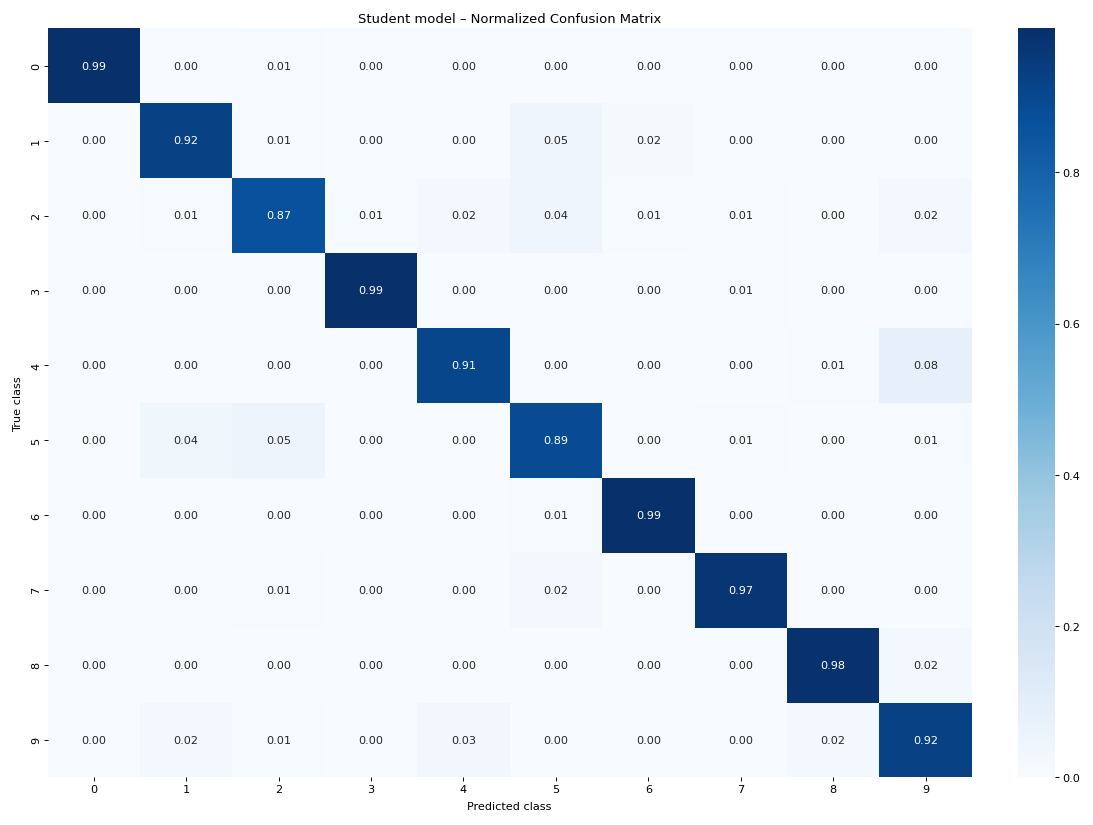

In [17]:
class_names = [
    '0', '1', '2', '3', '4',
    '5', '6', '7', '8', '9'
]

cm = confusion_matrix_with_plot(
    model=student,
    dataloader=test_loader,
    class_names=class_names,
    normalize='true',
    title="Student model – Normalized Confusion Matrix"
)

#### Distillation Training Functions

In [18]:
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, targets, T=4.0, alpha=0.3):
    # Hard loss
    ce = F.cross_entropy(student_logits, targets)

    # Soft loss
    p_s = F.log_softmax(student_logits / T, dim=1)
    p_t = F.softmax(teacher_logits / T, dim=1)

    kl = F.kl_div(p_s, p_t, reduction="batchmean")

    return alpha * ce + (1 - alpha) * (T ** 2) * kl


In [19]:
def train_kd_epoch(student, teacher, loader, optimizer, T=4.0, alpha=0.3):
    student.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            teacher_logits = teacher(x)

        student_logits = student(x)
        loss = distillation_loss(
            student_logits,
            teacher_logits,
            y,
            T=T,
            alpha=alpha
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        # accuracy
        preds = student_logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc


In [20]:
@torch.no_grad()
def eval_kd_epoch(student, teacher, loader, T=4.0, alpha=0.3):
    """
    Evaluate the student on a dataset.
    If teacher is provided, compute distillation loss.
    Returns average loss and accuracy.
    """
    student.eval()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        student_logits = student(x)

        if teacher is not None:
            teacher_logits = teacher(x)
            loss = distillation_loss(student_logits, teacher_logits, y, T=T, alpha=alpha)
        else:
            loss = F.cross_entropy(student_logits, y)

        total_loss += loss.item() * x.size(0)
        preds = student_logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


#### Distilled Student 

In [21]:
wandb.init(
    project="mnist-1d-KDvsLTH",
    name="KD-Student",
    group="StudentCNN",
    config={
        "learning_rate": 1e-2,
        "weight_decay": 1e-4,
        "T_start": 12,
        "T_end": 8,
        "alpha": 0.2,
        "epochs": 500,
        "patience": 50,
        "architecture": "StudentCNN",
        "scheduler": "CosineAnnealingLR"
    }
)

student = StudentCNN().to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
epochs = wandb.config.epochs
T_start = wandb.config.T_start  # 10 from your config
T_end = wandb.config.T_end
alpha = wandb.config.alpha  # weighting between hard and soft loss
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
#early_stopper = EarlyStopping(patience=wandb.config.patience)

best_test_acc = 0.0
try:
    for epoch in range(epochs):
        # temperature decay
        T = T_start - (T_start - T_end) * (epoch / (epochs - 1))
        # Train student with KD
        train_loss, train_acc = train_kd_epoch(student, teacher, train_loader, optimizer, T=T, alpha=alpha)

        # Evaluate student with KD (teacher provided)
        test_loss, test_acc = eval_kd_epoch(student, teacher, test_loader, T=T, alpha=alpha)

        scheduler.step()

        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "temperature": T
        }, step=epoch)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train acc: {train_acc:.3f} | "
            f"Test acc: {test_acc:.3f}"
        )
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(student.state_dict(), "best_kd_student_model.pth")
            wandb.save("best_kd_student_model.pth")
        # Check Early Stopping
        #early_stopper(test_loss)
        #if early_stopper.early_stop:
        #    print(f"Early stopping triggered at epoch {epoch+1}")
        #    break
finally:
    wandb.finish()


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 01 | Train acc: 0.206 | Test acc: 0.255
Epoch 02 | Train acc: 0.341 | Test acc: 0.462
Epoch 03 | Train acc: 0.494 | Test acc: 0.467
Epoch 04 | Train acc: 0.636 | Test acc: 0.663
Epoch 05 | Train acc: 0.688 | Test acc: 0.697
Epoch 06 | Train acc: 0.752 | Test acc: 0.724
Epoch 07 | Train acc: 0.770 | Test acc: 0.763
Epoch 08 | Train acc: 0.792 | Test acc: 0.809
Epoch 09 | Train acc: 0.832 | Test acc: 0.799
Epoch 10 | Train acc: 0.843 | Test acc: 0.848
Epoch 11 | Train acc: 0.864 | Test acc: 0.854
Epoch 12 | Train acc: 0.882 | Test acc: 0.869
Epoch 13 | Train acc: 0.893 | Test acc: 0.882
Epoch 14 | Train acc: 0.905 | Test acc: 0.906
Epoch 15 | Train acc: 0.917 | Test acc: 0.902
Epoch 16 | Train acc: 0.920 | Test acc: 0.907
Epoch 17 | Train acc: 0.930 | Test acc: 0.917
Epoch 18 | Train acc: 0.942 | Test acc: 0.930
Epoch 19 | Train acc: 0.943 | Test acc: 0.918
Epoch 20 | Train acc: 0.948 | Test acc: 0.912
Epoch 21 | Train acc: 0.949 | Test acc: 0.929
Epoch 22 | Train acc: 0.952 | Test

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 500 | Train acc: 0.998 | Test acc: 0.955


temperature,████▇▇▇▇▇▇▇▇▇▇▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁
test_acc,▁▇▇▇▇█████████████▇██████████████████▇██
test_loss,█▇▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▆▇▇████████████████████████████████████
train_loss,█▇▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
temperature,8
test_acc,0.955
test_loss,1.61598
train_acc,0.99775
train_loss,0.53731


In [22]:
student.load_state_dict(torch.load("best_kd_student_model.pth"))
final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
print(f"Best Knoledge Distilled Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Best Knoledge Distilled Student model - Acc: 0.9630 | Loss: 0.1944


In [ ]:
class_names = [
    '0', '1', '2', '3', '4',
    '5', '6', '7', '8', '9'
]

cm = confusion_matrix_with_plot(
    model=student,
    dataloader=test_loader,
    class_names=class_names,
    normalize='true',
    title="Student model – Normalized Confusion Matrix"
)

#### MLP Student

In [115]:

class StudentMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),             # input shape: (batch, 40) → flattened
            nn.Linear(40, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)        # output logits
        )

    def forward(self, x):
        # x shape: (batch, 1, 40) → remove channel dimension
        x = x.squeeze(1)
        return self.net(x)
    
studentMLP = StudentMLP().to(device)
count = sum(p.numel() for p in studentMLP.parameters() if p.requires_grad)
print(f'Student MLP parameters: {count}')

Student MLP parameters: 337930


In [116]:
studentMLP = StudentMLP().to(device)
optimizer = torch.optim.Adam(studentMLP.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
epochs = 100

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(studentMLP, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(studentMLP, test_loader,   criterion)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train acc: {train_acc:.3f} | "
        f"Test acc: {test_acc:.3f}"
    )

Epoch 01 | Train acc: 0.273 | Test acc: 0.405
Epoch 02 | Train acc: 0.398 | Test acc: 0.446
Epoch 03 | Train acc: 0.420 | Test acc: 0.453
Epoch 04 | Train acc: 0.440 | Test acc: 0.467
Epoch 05 | Train acc: 0.458 | Test acc: 0.490
Epoch 06 | Train acc: 0.473 | Test acc: 0.483
Epoch 07 | Train acc: 0.499 | Test acc: 0.522
Epoch 08 | Train acc: 0.522 | Test acc: 0.524
Epoch 09 | Train acc: 0.542 | Test acc: 0.581
Epoch 10 | Train acc: 0.563 | Test acc: 0.562
Epoch 11 | Train acc: 0.576 | Test acc: 0.602
Epoch 12 | Train acc: 0.585 | Test acc: 0.613
Epoch 13 | Train acc: 0.608 | Test acc: 0.616
Epoch 14 | Train acc: 0.631 | Test acc: 0.626
Epoch 15 | Train acc: 0.619 | Test acc: 0.632
Epoch 16 | Train acc: 0.625 | Test acc: 0.641
Epoch 17 | Train acc: 0.643 | Test acc: 0.648
Epoch 18 | Train acc: 0.659 | Test acc: 0.649
Epoch 19 | Train acc: 0.665 | Test acc: 0.669
Epoch 20 | Train acc: 0.673 | Test acc: 0.666
Epoch 21 | Train acc: 0.672 | Test acc: 0.671
Epoch 22 | Train acc: 0.685 | Test

In [118]:
studentMLP = StudentMLP().to(device)
optimizer = torch.optim.Adam(studentMLP.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 200
T = 8    # temperature
alpha = 0.2  # weighting between hard and soft loss

for epoch in range(epochs):
    # Train student with KD
    train_loss, train_acc = train_kd_epoch(studentMLP, teacher, train_loader, optimizer, T=T, alpha=alpha)

    # Evaluate student with KD (teacher provided)
    test_loss, test_acc = eval_kd_epoch(studentMLP, teacher, test_loader, T=T, alpha=alpha)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train acc: {train_acc:.3f} | "
        f"Test acc: {test_acc:.3f}"
    )


Epoch 01 | Train acc: 0.269 | Test acc: 0.344
Epoch 02 | Train acc: 0.347 | Test acc: 0.415
Epoch 03 | Train acc: 0.384 | Test acc: 0.472
Epoch 04 | Train acc: 0.423 | Test acc: 0.479
Epoch 05 | Train acc: 0.439 | Test acc: 0.479
Epoch 06 | Train acc: 0.458 | Test acc: 0.498
Epoch 07 | Train acc: 0.468 | Test acc: 0.515
Epoch 08 | Train acc: 0.478 | Test acc: 0.543
Epoch 09 | Train acc: 0.515 | Test acc: 0.555
Epoch 10 | Train acc: 0.533 | Test acc: 0.561
Epoch 11 | Train acc: 0.532 | Test acc: 0.586
Epoch 12 | Train acc: 0.567 | Test acc: 0.594
Epoch 13 | Train acc: 0.574 | Test acc: 0.604
Epoch 14 | Train acc: 0.588 | Test acc: 0.623
Epoch 15 | Train acc: 0.603 | Test acc: 0.628
Epoch 16 | Train acc: 0.620 | Test acc: 0.628
Epoch 17 | Train acc: 0.620 | Test acc: 0.652
Epoch 18 | Train acc: 0.623 | Test acc: 0.659
Epoch 19 | Train acc: 0.621 | Test acc: 0.678
Epoch 20 | Train acc: 0.636 | Test acc: 0.673
Epoch 21 | Train acc: 0.644 | Test acc: 0.672
Epoch 22 | Train acc: 0.648 | Test

## Lottery Ticket Hypotesis

### Big starting CNN definition

In [11]:
import torch
import torch.nn as nn

class BigCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1D-CNN backbone with Batch Normalization
        self.features = nn.Sequential(
            # Block 1: Input (B, 1, 40)
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2), # -> (B, 128, 10)
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # Global Average Pooling ensures the model is robust to 
            # where the digit "signal" appears in the sequence.
            nn.AdaptiveAvgPool1d(1) # -> (B, 256, 1)
        )

        # Wider Classification Head for higher capacity
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #nn.Linear(128, 128), 
            #nn.ReLU(),
            #nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        # Ensure input shape is (Batch, Channels, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = BigCNN().to(device)
teacher = BigCNN().to(device)
count = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
print(f'Teacher CNN parameters: {count}')

Teacher CNN parameters: 60938


In [13]:
import torch
import torch.nn as nn

class BigCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1D-CNN backbone with Batch Normalization
        self.features = nn.Sequential(
            # Block 1: Input (B, 1, 40)
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2), # -> (B, 128, 10)
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # Global Average Pooling ensures the model is robust to 
            # where the digit "signal" appears in the sequence.
            nn.AdaptiveAvgPool1d(1) # -> (B, 256, 1)
        )

        # Wider Classification Head for higher capacity
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #nn.Linear(128, 128), 
            #nn.ReLU(),
            #nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        # Ensure input shape is (Batch, Channels, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BigModel = BigCNN().to(device)
count = sum(p.numel() for p in BigModel.parameters() if p.requires_grad)
print(f'Big CNN parameters: {count}')

Big CNN parameters: 40458


In [34]:
teacher = BigCNN().to(device)
optimizer = torch.optim.Adam(teacher.parameters(), lr=1e-2)
epochs = 200
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.CrossEntropyLoss()

#early_stopper = EarlyStopping(patience=wandb.config.patience)


best_test_acc = 0.0
model_path = "best_big_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(teacher, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(teacher, test_loader, criterion)

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(teacher.state_dict(), model_path)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Test Acc: {test_acc:.3f} | Train Acc: {train_acc:.3f} | LR: {current_lr:.6f}")

print("\nTraining complete. Loading best model for final evaluation...")
teacher.load_state_dict(torch.load(model_path))

# 4. Final Evaluation
final_loss, final_acc = eval_epoch(teacher, test_loader, criterion)

print(f"Final Verification - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Epoch 010 | Test Acc: 0.968 | Train Acc: 0.919 | LR: 0.009938
Epoch 020 | Test Acc: 0.975 | Train Acc: 0.948 | LR: 0.009755
Epoch 030 | Test Acc: 0.983 | Train Acc: 0.965 | LR: 0.009455
Epoch 040 | Test Acc: 0.990 | Train Acc: 0.977 | LR: 0.009045
Epoch 050 | Test Acc: 0.989 | Train Acc: 0.971 | LR: 0.008536
Epoch 060 | Test Acc: 0.987 | Train Acc: 0.976 | LR: 0.007939
Epoch 070 | Test Acc: 0.984 | Train Acc: 0.981 | LR: 0.007270
Epoch 080 | Test Acc: 0.985 | Train Acc: 0.979 | LR: 0.006545
Epoch 090 | Test Acc: 0.988 | Train Acc: 0.986 | LR: 0.005782
Epoch 100 | Test Acc: 0.989 | Train Acc: 0.987 | LR: 0.005000
Epoch 110 | Test Acc: 0.991 | Train Acc: 0.990 | LR: 0.004218
Epoch 120 | Test Acc: 0.990 | Train Acc: 0.993 | LR: 0.003455
Epoch 130 | Test Acc: 0.992 | Train Acc: 0.992 | LR: 0.002730
Epoch 140 | Test Acc: 0.990 | Train Acc: 0.991 | LR: 0.002061
Epoch 150 | Test Acc: 0.991 | Train Acc: 0.993 | LR: 0.001464
Epoch 160 | Test Acc: 0.992 | Train Acc: 0.995 | LR: 0.000955
Epoch 17

In [13]:
BigModel.load_state_dict(torch.load("best_big_model.pth"))
final_loss, final_acc = eval_epoch(BigModel, test_loader, nn.CrossEntropyLoss())
print(f"Best Big CNN model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Best Big CNN model - Acc: 0.9950 | Loss: 0.0257


### LTH helper functions

In [15]:
# --- Helper Functions for LTH ---

def get_prunable_layers(model):
    """
    Returns a list of modules that we want to prune.
    Typically Conv1d and Linear layers. We usually skip BatchNorm.
    """
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            layers.append((module, 'weight'))
    return layers

In [16]:
def train_model(model, device, train_loader, test_loader, optimizer, scheduler, epochs, round_idx):
    model.train()
    history = {'val_acc': []}
    criterion = nn.CrossEntropyLoss()
    
    best_test_acc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
        
        val_acc = 100. * correct / len(test_loader.dataset)
        history['val_acc'].append(val_acc)

        if val_acc > best_test_acc:
            best_test_acc = val_acc
            # Save the best model for this round
            torch.save(model.state_dict(), f'best_lth_model_round_{round_idx}.pth')
        
        # Log to W&B
        # We use a combined index for the x-axis to see the total progress
        wandb.log({
            f"round_{round_idx}/val_acc": val_acc,
            f"round_{round_idx}/train_loss": total_loss / len(train_loader),
            #"global_epoch": (round_idx * epochs) + epoch
        })
        print(f"Round {round_idx} | Epoch {epoch+1} | Val Acc: {val_acc:.2f}%")
    return history

In [17]:
def remove_pruning_reparam(model):
    """
    Makes the pruning permanent so we can check sparsity easily.
    Required before saving the 'winning ticket' or doing inference analysis.
    """
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            try:
                prune.remove(module, 'weight')
            except ValueError:
                pass # Layer wasn't pruned

In [18]:
def count_sparsity(model):
    """Calculates global sparsity"""
    sum_zeros = 0
    sum_elements = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            sum_zeros += torch.sum(module.weight == 0)
            sum_elements += module.weight.nelement()
    
    if sum_elements == 0: return 0
    return 100.0 * float(sum_zeros) / float(sum_elements)

In [19]:
def count_active_parameters(model):
    """
    Counts the number of non-zero parameters in the model.
    """
    total_active = 0
    total_params = 0
    
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            # Get the weight (handles both pruned and unpruned states)
            w = module.weight.data
            
            active = torch.count_nonzero(w).item()
            total = w.numel()
            
            total_active += active
            total_params += total
            
            # Optional: Print per-layer breakdown
            print(f"Layer: {name:20} | Active: {active:8} / {total:8} ({100*active/total:.2f}%)")
            
    print("-" * 60)
    print(f"TOTAL ACTIVE PARAMETERS: {total_active:,} / {total_params:,}")
    print(f"GLOBAL DENSITY: {100 * total_active / total_params:.2f}%")
    
    return total_active

### LTH training

In [ ]:
def run_lth(train_loader, test_loader, rounds=5, prune_amount=0.2, epochs_per_round=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize Network
    model = BigCNN().to(device)
    wandb.watch(model, log="all")
    
    # Save Initial State (Theta_0)
    initial_state = copy.deepcopy(model.state_dict())
    
    print(f"Initial parameters: {sum(p.numel() for p in model.parameters())}")

    for round_idx in range(rounds):
        print(f"\n--- Round {round_idx + 1} ---")
        
        # Train (Re-init optimizer to reset momentum)
        optimizer = optim.Adam(model.parameters(), lr=0.001) 
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs_per_round)
        
        history = train_model(
        model, 
        device, 
        train_loader, 
        test_loader, 
        optimizer,
        scheduler,
        epochs=epochs_per_round,
        round_idx=round_idx  # <--- Add this line
        )
        best_acc = max(history['val_acc'])

        # Calculate Sparsity
        sparsity_pct = count_sparsity(model)
        print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
        active_params = count_active_parameters(model)
        print(f"Active parameters after pruning: {active_params}")

        # Prune
        parameters_to_prune = get_prunable_layers(model)
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=prune_amount,
        )

        wandb.log({
            "active_parameters": active_params,
            "sparsity_percentage": sparsity_pct,
            "round": round_idx,
            "best_val_acc": best_acc
            })
        
        # Reset Weights (The Rewind)
        with torch.no_grad():
            for name, param in model.named_parameters():
                clean_name = name.replace("_orig", "")
                if clean_name in initial_state:
                     param.data.copy_(initial_state[clean_name].data)

        print("Weights reset to initialization.")

    remove_pruning_reparam(model)
    return model

In [21]:
# Initialize your project
wandb.init(
    project="mnist-1d-KDvsLTH",
    group="LTH-TeacherCNN",
    config={
        "learning_rate": 0.001,
        "rounds": 15,
        "prune_amount": 0.2,
        "epochs_per_round": 200,
        "architecture": "TeacherCNN"
    }
)


# Assuming you have your loaders ready
pruned_model = run_lth(
    train_loader, 
    test_loader, 
    rounds=wandb.config.rounds, 
    prune_amount=wandb.config.prune_amount, 
    epochs_per_round=wandb.config.epochs_per_round
)

wandb: Currently logged in as: matteo-piras (matteo-piras-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Initial parameters: 40458

--- Round 1 ---
Round 0 | Epoch 1 | Val Acc: 29.20%
Round 0 | Epoch 2 | Val Acc: 59.80%
Round 0 | Epoch 3 | Val Acc: 67.90%
Round 0 | Epoch 4 | Val Acc: 68.40%
Round 0 | Epoch 5 | Val Acc: 70.20%
Round 0 | Epoch 6 | Val Acc: 71.00%
Round 0 | Epoch 7 | Val Acc: 70.90%
Round 0 | Epoch 8 | Val Acc: 71.00%
Round 0 | Epoch 9 | Val Acc: 73.00%
Round 0 | Epoch 10 | Val Acc: 72.80%
Round 0 | Epoch 11 | Val Acc: 78.10%
Round 0 | Epoch 12 | Val Acc: 80.30%
Round 0 | Epoch 13 | Val Acc: 83.80%
Round 0 | Epoch 14 | Val Acc: 87.60%
Round 0 | Epoch 15 | Val Acc: 91.50%
Round 0 | Epoch 16 | Val Acc: 91.00%
Round 0 | Epoch 17 | Val Acc: 92.20%
Round 0 | Epoch 18 | Val Acc: 92.00%
Round 0 | Epoch 19 | Val Acc: 91.90%
Round 0 | Epoch 20 | Val Acc: 92.50%
Round 0 | Epoch 21 | Val Acc: 92.30%
Round 0 | Epoch 22 | Val Acc: 92.00%
Round 0 | Epoch 23 | Val Acc: 90.90%
Round 0 | Epoch 24 | Val Acc: 92.70%
Round 0 | Epoch 25 | Val Acc: 93.70%
Round 0 | Epoch 26 | Val Acc: 93.70%
Roun

In [32]:
model = BigCNN().to(device)

parameters_to_prune = get_prunable_layers(model)
prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2,
)

model.load_state_dict(torch.load("best_lth_model_round_6.pth", map_location=device))
final_loss, final_acc = eval_epoch(model, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
# Calculate Sparsity
sparsity_pct = count_sparsity(model)
print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
active_params = count_active_parameters(model)
print(f"Active parameters after pruning: {active_params}")


LTH Pruned model - Acc: 0.9880 | Loss: 0.0457
Sparsity after pruning: 73.79%
Layer: features.0           | Active:      126 /      160 (78.75%)
Layer: features.5           | Active:     1193 /     6144 (19.42%)
Layer: features.10          | Active:     3534 /    24576 (14.38%)
Layer: classifier.1         | Active:     5039 /     8192 (61.51%)
Layer: classifier.4         | Active:      518 /      640 (80.94%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 10,410 / 39,712
GLOBAL DENSITY: 26.21%
Active parameters after pruning: 10410


## Evaluating penultimate layer similarity using CKA metric

### Models Loading

In [71]:
teacher = TeacherCNN().to(device)
teacher.load_state_dict(torch.load("best_teacher_model.pth", map_location=device))
final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss())
print(f"Teacher CNN model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
count = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
print(f'Teacher CNN parameters: {count}')
for name, module in teacher.named_modules():
    print(name, module.__class__.__name__)


Teacher CNN model - Acc: 0.9930 | Loss: 0.0262
Teacher CNN parameters: 999562
 TeacherCNN
features Sequential
features.0 Conv1d
features.1 BatchNorm1d
features.2 ReLU
features.3 MaxPool1d
features.4 Dropout
features.5 Conv1d
features.6 BatchNorm1d
features.7 ReLU
features.8 MaxPool1d
features.9 Dropout
features.10 Conv1d
features.11 BatchNorm1d
features.12 ReLU
features.13 AdaptiveAvgPool1d
classifier Sequential
classifier.0 Flatten
classifier.1 Linear
classifier.2 ReLU
classifier.3 Dropout
classifier.4 Linear
classifier.5 ReLU
classifier.6 Dropout
classifier.7 Linear


In [25]:
student = StudentCNN().to(device)
student.load_state_dict(torch.load("best_kd_student_model.pth"))
final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
print(f"KD Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
count = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f'Student CNN parameters: {count}')
print(student)

KD Student model - Acc: 0.9630 | Loss: 0.1944
Student CNN parameters: 6426
StudentCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(2,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [63]:
lth_baseline = BigCNN().to(device)
#parameters_to_prune = get_prunable_layers(lth_baseline)
#prune.global_unstructured(
#    parameters_to_prune,
#    pruning_method=prune.L1Unstructured,
#    amount=0.2,
#)

lth_baseline.load_state_dict(torch.load("best_lth_model_round_0.pth", map_location=device))
final_loss, final_acc = eval_epoch(lth_baseline, test_loader, nn.CrossEntropyLoss())
print(f"LTH Baseline - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
# Calculate Sparsity
#sparsity_pct = count_sparsity(lth_baseline)
#print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
active_params = count_active_parameters(lth_baseline)
print(f"Active parameters after pruning: {active_params}")

LTH Baseline - Acc: 0.9900 | Loss: 0.0393
Layer: features.0           | Active:      160 /      160 (100.00%)
Layer: features.5           | Active:     6144 /     6144 (100.00%)
Layer: features.10          | Active:    24576 /    24576 (100.00%)
Layer: classifier.1         | Active:     8192 /     8192 (100.00%)
Layer: classifier.4         | Active:      640 /      640 (100.00%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 39,712 / 39,712
GLOBAL DENSITY: 100.00%
Active parameters after pruning: 39712


In [53]:
lottery_ticket = BigCNN().to(device)

parameters_to_prune = get_prunable_layers(lottery_ticket)
prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2,
)

lottery_ticket.load_state_dict(torch.load("best_lth_model_round_8.pth", map_location=device))
final_loss, final_acc = eval_epoch(lottery_ticket, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned lottery_ticket - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
# Calculate Sparsity
sparsity_pct = count_sparsity(lottery_ticket)
print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
active_params = count_active_parameters(lottery_ticket)
print(f"Active parameters after pruning: {active_params}")


LTH Pruned lottery_ticket - Acc: 0.9710 | Loss: 0.1166
Sparsity after pruning: 83.22%
Layer: features.0           | Active:      118 /      160 (73.75%)
Layer: features.5           | Active:      562 /     6144 (9.15%)
Layer: features.10          | Active:     1206 /    24576 (4.91%)
Layer: classifier.1         | Active:     4275 /     8192 (52.19%)
Layer: classifier.4         | Active:      501 /      640 (78.28%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 6,662 / 39,712
GLOBAL DENSITY: 16.78%
Active parameters after pruning: 6662


### CKA computation function

In [45]:
import torch
import numpy as np

def compute_cka_matrix(
    model_a,
    model_b,
    layers_a: dict,
    layers_b: dict,
    dataloader,
    device,
):
    """
    Computes a CKA similarity matrix between two models.

    Args:
        model_a, model_b: torch.nn.Module (already trained)
        layers_a, layers_b: dict {layer_name: module_path}
        dataloader: PyTorch dataloader (same inputs for both models)
        device: torch.device

    Returns:
        cka_matrix: np.ndarray [len(layers_a), len(layers_b)]
        layer_names_a, layer_names_b: ordered layer name lists
    """

    model_a.eval()
    model_b.eval()

    # ---------- Hook registration ----------
    def register_hooks(model, layer_dict):
        activations = {}

        def hook_fn(name):
            def hook(_, __, output):
                activations[name] = output.detach()
            return hook

        handles = []
        modules = dict(model.named_modules())

        for name, module_path in layer_dict.items():
            handles.append(
                modules[module_path].register_forward_hook(hook_fn(name))
            )

        return activations, handles

    acts_a, hooks_a = register_hooks(model_a, layers_a)
    acts_b, hooks_b = register_hooks(model_b, layers_b)

    # ---------- Storage ----------
    storage_a = {k: [] for k in layers_a}
    storage_b = {k: [] for k in layers_b}

    # ---------- Forward passes ----------
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)

            _ = model_a(x)
            _ = model_b(x)

            for k in storage_a:
                storage_a[k].append(acts_a[k].cpu())

            for k in storage_b:
                storage_b[k].append(acts_b[k].cpu())

    # ---------- Cleanup ----------
    for h in hooks_a + hooks_b:
        h.remove()

    # ---------- Concatenate ----------
    for k in storage_a:
        storage_a[k] = torch.cat(storage_a[k], dim=0)

    for k in storage_b:
        storage_b[k] = torch.cat(storage_b[k], dim=0)

    # ---------- CKA computation ----------
    def flatten(x):
        return x.view(x.size(0), -1)

    def linear_cka(X, Y):
        X = X - X.mean(dim=0, keepdim=True)
        Y = Y - Y.mean(dim=0, keepdim=True)

        hsic = torch.norm(X.T @ Y, p='fro') ** 2
        norm_x = torch.norm(X.T @ X, p='fro')
        norm_y = torch.norm(Y.T @ Y, p='fro')

        return (hsic / (norm_x * norm_y)).item()

    layer_names_a = list(layers_a.keys())
    layer_names_b = list(layers_b.keys())

    cka_matrix = np.zeros((len(layer_names_a), len(layer_names_b)))

    for i, la in enumerate(layer_names_a):
        Xa = flatten(storage_a[la])

        for j, lb in enumerate(layer_names_b):
            Xb = flatten(storage_b[lb])
            cka_matrix[i, j] = linear_cka(Xa, Xb)

    return cka_matrix, layer_names_a, layer_names_b


### Reppresentation similarity between Teacher and Student

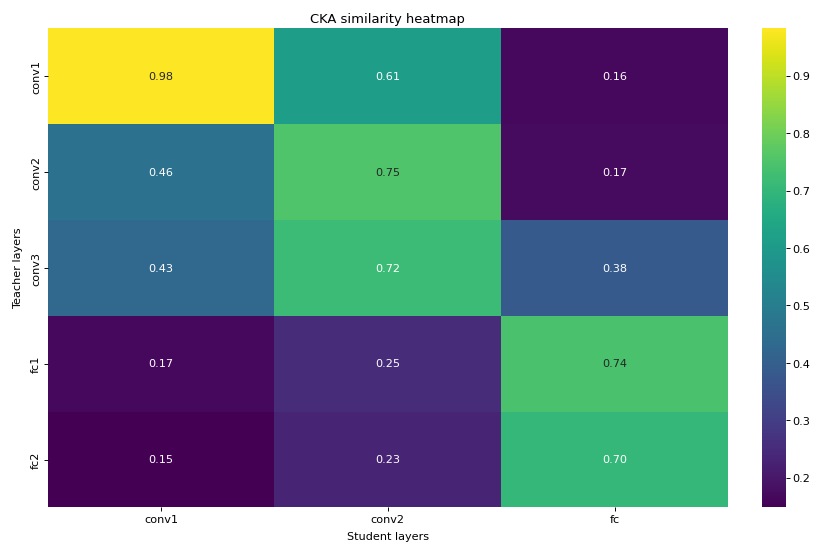

In [77]:
teacher_layers = {
    'conv1': 'features.0',
    'conv2': 'features.5',
    'conv3': 'features.10',
    'fc1': 'classifier.1',
    'fc2': 'classifier.4',
}

student_layers = {
    "conv1": "features.0",
    "conv2": "features.3",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    teacher,
    student,
    teacher_layers,
    student_layers,
    train_loader,
    device
)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Student layers")
plt.ylabel("Teacher layers")
plt.title("CKA similarity heatmap")

plt.show()

### Reppresentation similarity between Lottery Ticket and Baseline

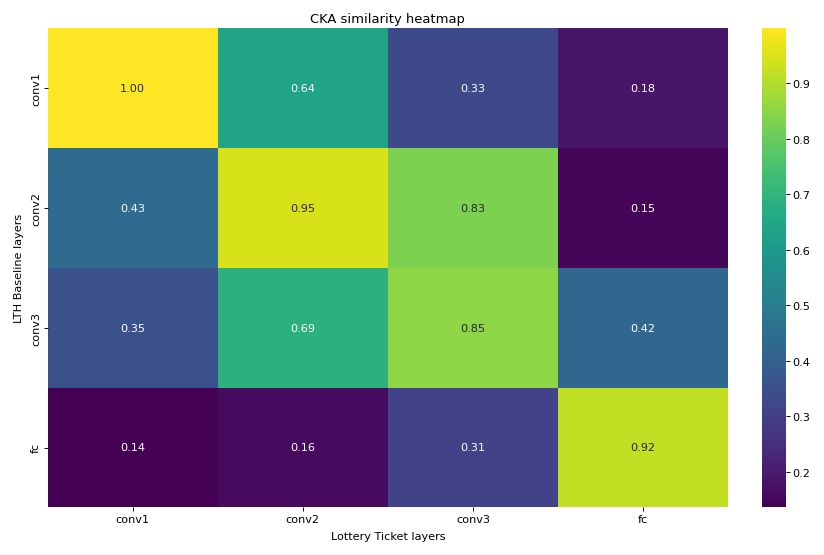

In [66]:
lth_baseline_layers = {
    "conv1": "features.0",
    "conv2": "features.5",
    "conv3": "features.10",
    "fc": "classifier.1"
}

lottery_ticket_layers = {
    "conv1": "features.0",
    "conv2": "features.5",
    "conv3": "features.10",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    lth_baseline,
    lottery_ticket,
    lth_baseline_layers,
    lottery_ticket_layers,
    train_loader,
    device
)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Lottery Ticket layers")
plt.ylabel("LTH Baseline layers")
plt.title("CKA similarity heatmap")

plt.show()

### Reppresentation similarity between KD Student and Lottery Ticket

In [ ]:
student_layers = {
    "conv1": "features.0",
    "conv2": "features.3",
    "fc": "classifier.1"
}

lottery_ticket_layers = {
    "conv1": "features.0",
    "conv2": "features.5",
    "conv3": "features.10",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    student,
    lottery_ticket,
    student_layers,
    lottery_ticket_layers,
    train_loader,
    device
)

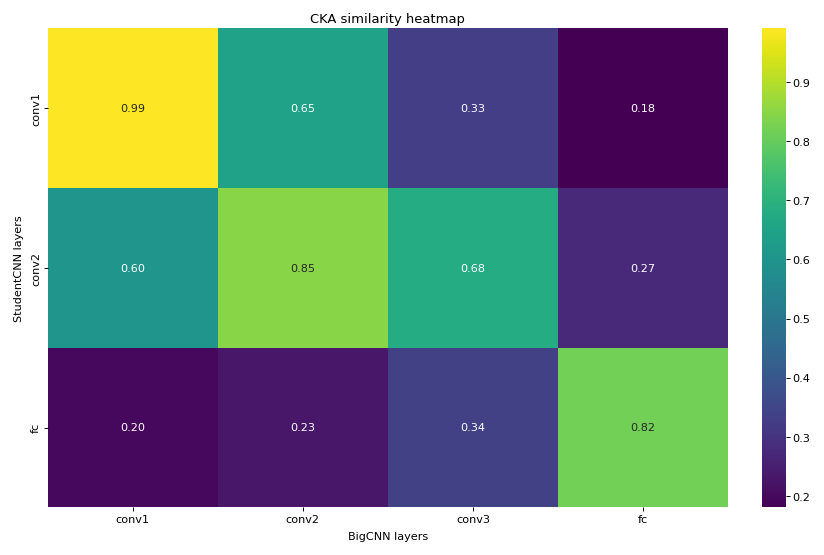

In [55]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("BigCNN layers")
plt.ylabel("StudentCNN layers")
plt.title("CKA similarity heatmap")

plt.show()


## WHAT'S NEXT?
1. Usando la metrica CKA confronta le rappresentazioni del penultimo layer FATTO
2. Potresti provare ad usare CKA per diagnosticare la KD
3. Prova ad aumentare il pruning per round -> piu pruning meno round -> meno round meno costo
4. Prova a creare una nuova rete student e un una nuova rete LTH che come penultimo layer portano ad uno spazio latente di dimensione 2 o 3 per confrontare le rappresentazioni apprese visisvamente 
5. Per ora le conclusioni sono che in teoria KD è meno costoso (anche se va considerato il costo di esplorare piu architetture student) ma offre prestazioni più scarse invece LTH è piu costoso ma offre prestazioni piu alte a parità di compressione (anche nel caso LTH va notato che la rete di partenza è importante dato che a prescindere dalla grandezza della rete di partenza mi risulta che quando scendi sotto il 10% dei parametri iniziali la performance ne risenta sempre, quindi più è piccola la rete di partenza piu sarà piccola la rete finale)